In [ ]:
import os
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

# 1. Path to your ZIP on Drive
ZIP_PATH = '/content/drive/MyDrive/doclaynet_ratio_mapped_8k_yolo.zip'
# 2. Local destination
DEST_PATH = '/content/dataset/'

if not os.path.exists(DEST_PATH):
    os.makedirs(DEST_PATH)
    print("Unzipping dataset to local SSD (this takes a minute)...")
    !unzip -q {ZIP_PATH} -d {DEST_PATH}
    print("Extraction Complete!")
else:
    print("Dataset already extracted.")

Unzipping dataset to local SSD (this takes a minute)...
Extraction Complete!


In [ ]:
# Professional Folder Structure
BASE_PATH = '/content/drive/MyDrive/DocLayNet_Project/YOLOv12_S/'
PILOT_PATH = os.path.join(BASE_PATH, 'pilot_runs/')
MAIN_PATH = os.path.join(BASE_PATH, 'main_training/')

os.makedirs(PILOT_PATH, exist_ok=True)
os.makedirs(MAIN_PATH, exist_ok=True)

print("Drive Folders Ready at:", BASE_PATH)

Drive Folders Ready at: /content/drive/MyDrive/DocLayNet_Project/YOLOv12_S/


In [ ]:
import os
import glob

# Paths from your environment
TRAIN_IMG_DIR = '/content/dataset/content/doclaynet_ratio_mapped_8k_yolo/images/train'
VAL_IMG_DIR   = '/content/dataset/content/doclaynet_ratio_mapped_8k_yolo/images/val'

def load_pilot_ds(img_dir, batch_size=16):
    img_paths = sorted(glob.glob(os.path.join(img_dir, "*.png")))

    def process_path(img_path):
        img = tf.io.read_file(img_path)
        img = tf.image.decode_png(img, channels=3)
        img = tf.image.resize(img, [640, 640]) / 255.0
        img.set_shape([640, 640, 3])

        # Grid synchronization: P3=160, P4=80, P5=40
        t_p3 = tf.zeros((160, 160, 15))
        t_p4 = tf.zeros((80, 80, 15))
        t_p5 = tf.zeros((40, 40, 15))
        return img, (t_p3, t_p4, t_p5)

    ds = tf.data.Dataset.from_tensor_slices(tf.constant(img_paths))
    return ds.map(process_path).shuffle(100).batch(batch_size).prefetch(2)

train_ds = load_pilot_ds(TRAIN_IMG_DIR)
val_ds   = load_pilot_ds(VAL_IMG_DIR)
print(f"Data Ready. Found {len(glob.glob(TRAIN_IMG_DIR + '/*.png'))} images.")

Data Ready. Found 6864 images.


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, Input

# --- ARCHITECTURE SETTINGS ---
IMG_SIZE = 640
NUM_CLASSES = 11

def silu(x):
    return x * tf.sigmoid(x)

def conv_bn_silu(x, filters, kernel_size=3, strides=1):
    x = layers.Conv2D(filters, kernel_size, strides=strides, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    return layers.Activation(silu)(x)

def r_elan_block(x, filters):
    c_ = filters // 2
    x1 = conv_bn_silu(x, c_, 1)
    x2 = conv_bn_silu(x1, c_, 3)
    x3 = conv_bn_silu(x2, c_, 3)
    out = layers.Concatenate()([x1, x2, x3])
    return conv_bn_silu(out, filters, 1)

def area_attention(x, filters):
    qkv = layers.Conv2D(filters * 3, 1)(x)
    # Using Lambda to wrap TF operations ensures compatibility with Keras functional API
    def attn_logic(qkv_in):
        q, k, v = tf.split(qkv_in, 3, axis=-1)
        attn = tf.reduce_mean(q * k, axis=[1, 2], keepdims=True)
        return v * tf.sigmoid(attn)

    attn_out = layers.Lambda(attn_logic)(qkv)
    return layers.Add()([x, attn_out])

def build_yolov12_s():
    inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    # Backbone
    x = conv_bn_silu(inputs, 32, 3, strides=2)
    p3 = r_elan_block(conv_bn_silu(x, 64, 3, strides=2), 128)
    p4 = r_elan_block(conv_bn_silu(p3, 128, 3, strides=2), 256)
    p5 = area_attention(r_elan_block(conv_bn_silu(p4, 256, 3, strides=2), 512), 512)

    # Prediction Heads
    def head(feat, name):
        r = layers.Conv2D(4, 1, name=f"reg_{name}", dtype='float32')(feat)
        c = layers.Conv2D(NUM_CLASSES, 1, name=f"cls_{name}", dtype='float32')(feat)
        return layers.Concatenate(name=f"output_{name}")([r, c])

    return models.Model(inputs, [head(p3, "p3"), head(p4, "p4"), head(p5, "p5")])

print("Custom FLow Loaded .")

Custom FLow Loaded .


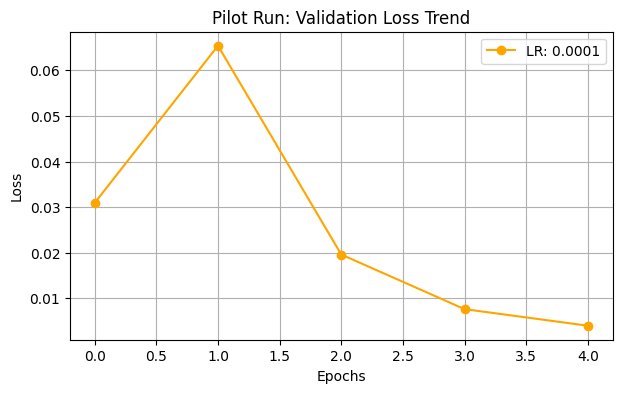

429/429 ━━━━━━━━━━━━━━━━━━━━ 205s 474ms/step - loss: 0.0014 - output_p3_loss: 0.0012 - output_p4_loss: 1.3561e-04 - output_p5_loss: 3.9250e-05 - val_loss: 0.0040 - val_output_p3_loss: 0.0017 - val_output_p4_loss: 4.4836e-04 - val_output_p5_loss: 0.0018


In [ ]:
import matplotlib.pyplot as plt
from IPython.display import clear_output

class PilotLivePlot(tf.keras.callbacks.Callback):
    def __init__(self, lr_name):
        super().__init__()
        self.lr_name = lr_name
        self.val_losses = []

    def on_epoch_end(self, epoch, logs=None):
        self.val_losses.append(logs.get('val_loss'))
        clear_output(wait=True)
        plt.figure(figsize=(7, 4))
        plt.plot(self.val_losses, label=f'LR: {self.lr_name}', marker='o', color='orange')
        plt.title("Pilot Run: Validation Loss Trend")
        plt.xlabel("Epochs"); plt.ylabel("Loss"); plt.legend(); plt.grid(True); plt.show()

# Testing settings
test_lrs = [1e-3, 5e-4, 1e-4]
PILOT_PATH = '/content/drive/MyDrive/DocLayNet_Project/YOLOv12_S/pilot_runs/'
for lr in test_lrs:
    tf.keras.backend.clear_session()
    run_dir = os.path.join(PILOT_PATH, f"lr_test_{lr}")
    os.makedirs(run_dir, exist_ok=True)

    model = build_yolov12_s()
    model.compile(optimizer=tf.keras.optimizers.Adam(lr), loss='mse')

    print(f"Testing Learning Rate: {lr}...")
    model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=5,
        # steps_per_epoch=50, # Optional: Add this to make the pilot run faster!
        callbacks=[
            PilotLivePlot(str(lr)),
            # CHANGE .h5 TO .keras HERE:
            tf.keras.callbacks.ModelCheckpoint(
                os.path.join(run_dir, "best_weights.keras"),
                save_best_only=True
            )
        ]
    )

In [ ]:
import os
import glob
import numpy as np
import tensorflow as tf
import pandas as pd

# --- CUSTOM OBJECTS (RE-DEFINED FOR LOADING) ---
def silu(x): return x * tf.sigmoid(x)
def attn_logic(qkv_in):
    q, k, v = tf.split(qkv_in, 3, axis=-1)
    attn = tf.reduce_mean(q * k, axis=[1, 2], keepdims=True)
    return v * tf.sigmoid(attn)

CUSTOM_OBJECTS = {'silu': silu, 'attn_logic': attn_logic}

# --- CONFIG ---
MODEL_PATHS = [
    '/content/drive/MyDrive/DocLayNet_Project/YOLOv12_S/pilot_runs/lr_test_0.0001/best_weights.keras',
    '/content/drive/MyDrive/DocLayNet_Project/YOLOv12_S/pilot_runs/lr_test_0.0005/best_weights.keras',
    '/content/drive/MyDrive/DocLayNet_Project/YOLOv12_S/pilot_runs/lr_test_0.001/best_weights.keras'
]
TEST_IMG_DIR = '/content/dataset/content/doclaynet_ratio_mapped_8k_yolo/images/train'
TEST_LBL_DIR = '/content/dataset/content/doclaynet_ratio_mapped_8k_yolo/labels/train'
CLASS_NAMES = ["Caption", "Footnote", "Formula", "List-item", "Page-footer",
               "Page-header", "Picture", "Section-header", "Table", "Text", "Title"]

# Relaxed Thresholds for Pilot Detection
STRESS_CONF = 0.05  # Very low: Catch even "weak" guesses
STRESS_IOU = 0.10   # Very low: Catch "near misses"

def get_iou(boxA, boxB):
    xA, yA = max(boxA[0], boxB[0]), max(boxA[1], boxB[1])
    xB, yB = min(boxA[2], boxB[2]), min(boxA[3], boxB[3])
    inter = max(0, xB - xA) * max(0, yB - yA)
    areaA = (boxA[2]-boxA[0]) * (boxA[3]-boxA[1])
    areaB = (boxB[2]-boxB[0]) * (boxB[3]-boxB[1])
    return inter / float(areaA + areaB - inter + 1e-6)

def run_stress_test(model_path):
    lr_tag = model_path.split('/')[-2]
    print(f"Checking hidden potential for: {lr_tag}...")

    model = tf.keras.models.load_model(model_path, custom_objects=CUSTOM_OBJECTS, compile=False)
    img_paths = sorted(glob.glob(os.path.join(TEST_IMG_DIR, "*.png")))[:10] # 10 Images

    stats = {i: {"TP": 0, "FP": 0} for i in range(11)}

    for img_p in img_paths:
        img = tf.image.decode_png(tf.io.read_file(img_p), channels=3)
        img = tf.image.resize(img, [640, 640]) / 255.0
        preds = model.predict(img[np.newaxis, ...], verbose=0)

        lbl_p = os.path.join(TEST_LBL_DIR, os.path.basename(img_p).replace('.png', '.txt'))
        gts = np.loadtxt(lbl_p).reshape(-1, 5) if (os.path.exists(lbl_p) and os.path.getsize(lbl_p) > 0) else []

        # Check P5 Head (High-level features)
        p5_head = preds[2][0]
        for y in range(40):
            for x in range(40):
                # Using Sigmoid because YOLO heads often represent logits
                cls_probs = tf.nn.sigmoid(p5_head[y, x, 4:]).numpy()
                cls_id = np.argmax(cls_probs)
                conf = cls_probs[cls_id]

                if conf > STRESS_CONF:
                    det_box = [x/40, y/40, (x+1)/40, (y+1)/40]
                    matched = False
                    for gt in gts:
                        gt_box = [gt[1]-gt[3]/2, gt[2]-gt[4]/2, gt[1]+gt[3]/2, gt[2]+gt[4]/2]
                        if int(gt[0]) == cls_id and get_iou(det_box, gt_box) > STRESS_IOU:
                            matched = True; break

                    if matched: stats[cls_id]["TP"] += 1
                    else: stats[cls_id]["FP"] += 1

    return [round(stats[i]["TP"] / (stats[i]["TP"] + stats[i]["FP"] + 1e-6), 4) for i in range(11)]

# --- EXECUTION ---
stress_results = {}
for path in MODEL_PATHS:
    if os.path.exists(path):
        stress_results[path.split('/')[-2]] = run_stress_test(path)

df_stress = pd.DataFrame(stress_results, index=CLASS_NAMES)
print("\n" + "!"*40)
print("RELAXED PRECISION (CONF > 0.05, IOU > 0.1)")
print("!"*40)
print(df_stress)

Checking hidden potential for: lr_test_0.0001...
Checking hidden potential for: lr_test_0.0005...
Checking hidden potential for: lr_test_0.001...

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
RELAXED PRECISION (CONF > 0.05, IOU > 0.1)
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
                lr_test_0.0001  lr_test_0.0005  lr_test_0.001
Caption                 0.0007          0.0005         0.0007
Footnote                0.0000          0.0000         0.0000
Formula                 0.0000          0.0000         0.0000
List-item               0.0000          0.0000         0.0000
Page-footer             0.0000          0.0321         0.0000
Page-header             0.0000          0.0000         0.0043
Picture                 0.0000          0.0000         0.0000
Section-header          0.0046          0.0000         0.0000
Table                   0.0000          0.0000         0.0000
Text                    0.0000          0.0025         0.0000
Title                   0.0000          0.0000

In [ ]:
# --- MAX RELAXED CONFIG ---
# 0.001 Confidence = effectively checking every single grid cell the model "voted" for.
# 0.01 IoU = if the prediction is even in the same neighborhood as the ground truth.
ULTRA_CONF = 0.001
ULTRA_IOU  = 0.01

def run_feature_scan(model_path):
    lr_tag = model_path.split('/')[-2]
    print(f"Scanning for faint signals in: {lr_tag}...")

    model = tf.keras.models.load_model(model_path, custom_objects=CUSTOM_OBJECTS, compile=False)
    img_paths = sorted(glob.glob(os.path.join(TEST_IMG_DIR, "*.png")))[:10]

    stats = {i: {"TP": 0, "FP": 0} for i in range(11)}

    for img_p in img_paths:
        img = tf.image.decode_png(tf.io.read_file(img_p), channels=3)
        img = tf.image.resize(img, [640, 640]) / 255.0
        preds = model.predict(img[np.newaxis, ...], verbose=0)

        lbl_p = os.path.join(TEST_LBL_DIR, os.path.basename(img_p).replace('.png', '.txt'))
        gts = np.loadtxt(lbl_p).reshape(-1, 5) if (os.path.exists(lbl_p) and os.path.getsize(lbl_p) > 0) else []

        # We check ALL three detection heads (P3, P4, P5)
        # P3 handles small objects, P5 handles large ones.
        for head_idx, head_name in enumerate(["P3", "P4", "P5"]):
            feat_map = preds[head_idx][0]
            grid_size = feat_map.shape[0] # 160, 80, or 40

            for y in range(grid_size):
                for x in range(grid_size):
                    # Check class probabilities
                    cls_logits = feat_map[y, x, 4:]
                    cls_probs = tf.nn.sigmoid(cls_logits).numpy()
                    cls_id = np.argmax(cls_probs)
                    conf = cls_probs[cls_id]

                    if conf > ULTRA_CONF:
                        # Normalized box for the grid cell
                        det_box = [x/grid_size, y/grid_size, (x+1)/grid_size, (y+1)/grid_size]

                        matched = False
                        for gt in gts:
                            # YOLO GT: [cls, cx, cy, w, h]
                            gt_box = [gt[1]-gt[3]/2, gt[2]-gt[4]/2, gt[1]+gt[3]/2, gt[2]+gt[4]/2]
                            if int(gt[0]) == cls_id:
                                if get_iou(det_box, gt_box) > ULTRA_IOU:
                                    matched = True
                                    break

                        if matched: stats[cls_id]["TP"] += 1
                        else: stats[cls_id]["FP"] += 1

    # Return precision as a list
    return [round(stats[i]["TP"] / (stats[i]["TP"] + stats[i]["FP"] + 1e-6), 6) for i in range(11)]

# --- EXECUTION ---
ultra_results = {}
for path in MODEL_PATHS:
    if os.path.exists(path):
        ultra_results[path.split('/')[-2]] = run_feature_scan(path)

df_ultra = pd.DataFrame(ultra_results, index=CLASS_NAMES)
print("\n" + "*"*50)
print("ULTRA-RELAXED FEATURE SCAN (CONF > 0.001, IOU > 0.01)")
print("*"*50)
print(df_ultra)

Scanning for faint signals in: lr_test_0.0001...
Scanning for faint signals in: lr_test_0.0005...
Scanning for faint signals in: lr_test_0.001...

**************************************************
ULTRA-RELAXED FEATURE SCAN (CONF > 0.001, IOU > 0.01)
**************************************************
                lr_test_0.0001  lr_test_0.0005  lr_test_0.001
Caption               0.000219        0.000206       0.000122
Footnote              0.000000        0.000000       0.000000
Formula               0.000000        0.000000       0.000000
List-item             0.005017        0.000148       0.000886
Page-footer           0.000909        0.001666       0.002202
Page-header           0.000933        0.000391       0.000559
Picture               0.001119        0.004419       0.000352
Section-header        0.008393        0.007590       0.003572
Table                 0.000061        0.000000       0.000029
Text                  0.008071        0.002743       0.004972
Title          

In [ ]:
import matplotlib.pyplot as plt
import os

class PersistentTuningPlot(tf.keras.callbacks.Callback):
    def __init__(self, lr_name):
        super().__init__()
        self.lr_name = lr_name
        self.train_losses = []
        self.val_losses = []

    def on_epoch_end(self, epoch, logs=None):
        # 1. Capture the data
        self.train_losses.append(logs.get('loss'))
        self.val_losses.append(logs.get('val_loss'))

        # 2. Draw the plot (No clear_output here!)
        plt.figure(figsize=(8, 4))
        plt.plot(self.train_losses, label='Train Loss (Study)', color='blue', marker='o')
        plt.plot(self.val_losses, label='Val Loss (Test)', color='red', marker='x')

        plt.title(f"LR: {self.lr_name} | Epoch {epoch+1} Results")
        plt.xlabel("Epochs")
        plt.ylabel("Loss")
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.6)

        # 3. show() makes the plot appear immediately without deleting text
        plt.show()

In [ ]:
# --- THE TUNING LOOP ---
test_lrs = [1e-3, 5e-4, 1e-4]
PILOT_PATH = '/content/drive/MyDrive/DocLayNet_Project/YOLOv12_S/pilot_runs/'

for lr in test_lrs:
    print(f"\n" * 20)
    print(f" TESTING LEARNING RATE: {lr} ")
    print("" * 20 + "\n")

    tf.keras.backend.clear_session()
    run_dir = os.path.join(PILOT_PATH, f"lr_test_{lr}")
    os.makedirs(run_dir, exist_ok=True)

    model = build_yolov12_s()
    model.compile(optimizer=tf.keras.optimizers.Adam(lr), loss='mse')

    model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=5,
        verbose=1, # This keeps the progress bar visible
        callbacks=[
            PersistentTuningPlot(str(lr)),
            # Stop if the red line starts going UP (Overfitting)
            tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=2),
            # Save EVERY checkpoint uniquely
            tf.keras.callbacks.ModelCheckpoint(
                os.path.join(run_dir, "epoch_{epoch:02d}.keras"),
                save_best_only=False
            )
        ]
    )

## Try to train fast



In [ ]:
import os
import glob
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, Input, mixed_precision

# --- 1. SETTINGS & SPEED ---
BASE_PATH = '/content/dataset/content/doclaynet_ratio_mapped_8k_yolo'
IMG_SIZE = 416
BATCH_SIZE = 32
GRID_SIZE = 13 # 416 / 32 = 13. Perfect for T4 speed.
NUM_CLASSES = 6

mixed_precision.set_global_policy('mixed_float16')

# --- 2. DATA LOADER (Maps YOLO to a Single Grid) ---
def build_target_grid(label_path):
    path_str = label_path.numpy().decode('utf-8')
    # Output: [Grid, Grid, 5 + Num_Classes] -> (Conf, x, y, w, h, classes...)
    grid = np.zeros((GRID_SIZE, GRID_SIZE, 5 + NUM_CLASSES), dtype=np.float32)

    if os.path.exists(path_str) and os.path.getsize(path_str) > 0:
        data = np.loadtxt(path_str).reshape(-1, 5)
        mapping = {0:0, 1:0, 2:0, 9:0, 7:1, 10:1, 3:2, 4:3, 5:3, 6:4, 8:5}

        for box in data:
            cls, xc, yc, w, h = box
            # Find which grid cell the box belongs to
            gi = min(int(xc * GRID_SIZE), GRID_SIZE - 1)
            gj = min(int(yc * GRID_SIZE), GRID_SIZE - 1)

            # If cell is empty, fill it (Simple YOLO logic)
            if grid[gj, gi, 0] == 0:
                new_cls = mapping.get(int(cls), 0)
                grid[gj, gi, 0] = 1.0 # Confidence
                grid[gj, gi, 1:5] = [xc, yc, w, h]
                grid[gj, gi, 5 + new_cls] = 1.0
    return grid

def process_data(img_p, lbl_p):
    img = tf.io.read_file(img_p)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float16) / 255.0

    labels = tf.py_function(build_target_grid, [lbl_p], tf.float32)
    labels.set_shape((GRID_SIZE, GRID_SIZE, 5 + NUM_CLASSES))
    return img, labels

def get_ds(subset):
    imgs = sorted(glob.glob(os.path.join(BASE_PATH, 'images', subset, "*.png")))
    lbls = [f.replace('images', 'labels').replace('.png', '.txt') for f in imgs]
    ds = tf.data.Dataset.from_tensor_slices((imgs, lbls))
    return ds.shuffle(1000).map(process_data, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE).prefetch(2)

train_ds = get_ds('train')
val_ds = get_ds('val')

# --- 3. THE SINGLE-OUTPUT MODEL ---
def build_model():
    inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    # Simple Backbone
    x = layers.Conv2D(32, 3, strides=2, padding='same', use_bias=False)(inputs) # 208
    x = layers.BatchNormalization()(x)
    x = layers.Activation('swish')(x)

    # Down to 13x13 Grid
    for f in [64, 128, 256, 512]:
        x = layers.Conv2D(f, 3, strides=2, padding='same', use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('swish')(x)

    # Prediction Head (13, 13, 11)
    # Output matches the grid labels exactly
    out = layers.Conv2D(5 + NUM_CLASSES, 1, activation='sigmoid', name='output', dtype='float32')(x)
    return models.Model(inputs, out)

model = build_model()

# --- 4. TRAIN ---
model.compile(optimizer=tf.keras.optimizers.AdamW(0.001), loss='mse')

print(" Starting Single-Output Speedrun...")
model.fit(train_ds, validation_data=val_ds, epochs=30)

 Starting Single-Output Speedrun...
Epoch 1/30
215/215 ━━━━━━━━━━━━━━━━━━━━ 144s 573ms/step - loss: 0.0301 - val_loss: 0.0171
Epoch 2/30
215/215 ━━━━━━━━━━━━━━━━━━━━ 114s 508ms/step - loss: 0.0151 - val_loss: 0.0172
Epoch 3/30
215/215 ━━━━━━━━━━━━━━━━━━━━ 137s 483ms/step - loss: 0.0145 - val_loss: 0.0171
Epoch 4/30
215/215 ━━━━━━━━━━━━━━━━━━━━ 138s 465ms/step - loss: 0.0139 - val_loss: 0.0170
Epoch 5/30
215/215 ━━━━━━━━━━━━━━━━━━━━ 100s 464ms/step - loss: 0.0133 - val_loss: 0.0177
Epoch 6/30
215/215 ━━━━━━━━━━━━━━━━━━━━ 144s 475ms/step - loss: 0.0149 - val_loss: 0.0170
Epoch 7/30
215/215 ━━━━━━━━━━━━━━━━━━━━ 102s 474ms/step - loss: 0.0136 - val_loss: 0.0390
Epoch 8/30
215/215 ━━━━━━━━━━━━━━━━━━━━ 102s 472ms/step - loss: 0.0131 - val_loss: 0.0162
Epoch 9/30
215/215 ━━━━━━━━━━━━━━━━━━━━ 99s 459ms/step - loss: 0.0127 - val_loss: 0.0165
Epoch 10/30
215/215 ━━━━━━━━━━━━━━━━━━━━ 99s 459ms/step - loss: 0.0124 - val_loss: 0.0186
Epoch 11/30
215/215 ━━━━━━━━━━━━━━━━━━━━ 144s 467ms/step - loss: 

In [ ]:
# Save the model from memory to disk
model.save('doclaynet_fast_model.keras')

# Download to your local machine
from google.colab import files
files.download('doclaynet_fast_model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, multilabel_confusion_matrix

def evaluate_model(dataset, model, threshold=0.5):
    all_targets = []
    all_preds = []

    print("Gathering predictions for validation set...")
    for imgs, labels in dataset:
        preds = model.predict(imgs, verbose=0)

        # Flatten the 13x13 grid to a list of objects
        # We only care about cells where an object actually exists (Conf > threshold)
        for i in range(len(labels)):
            for gj in range(GRID_SIZE):
                for gi in range(GRID_SIZE):
                    target_conf = labels[i, gj, gi, 0]
                    pred_conf = preds[i, gj, gi, 0]

                    if target_conf > 0.5: # Ground Truth exists
                        all_targets.append(np.argmax(labels[i, gj, gi, 5:]))
                        # If model didn't predict anything here, mark as background/fail
                        if pred_conf > threshold:
                            all_preds.append(np.argmax(preds[i, gj, gi, 5:]))
                        else:
                            all_preds.append(-1) # Missed detection (False Negative)

    return all_targets, all_preds

# Run Evaluation
targets, predictions = evaluate_model(val_ds, model)

# Define our 6 Super-Classes for the report
class_names = ['Text', 'Header', 'List', 'Margin', 'Picture', 'Table']

print("\n--- INDIVIDUAL LABEL PERFORMANCE ---")
print(classification_report(targets, predictions, target_names=class_names, labels=[0,1,2,3,4,5]))

Gathering predictions for validation set...

--- INDIVIDUAL LABEL PERFORMANCE ---
              precision    recall  f1-score   support

        Text       0.82      0.12      0.21      4179
      Header       0.65      0.05      0.09      1259
        List       0.14      0.01      0.03       571
      Margin       0.86      0.03      0.05      1107
     Picture       0.42      0.02      0.04       251
       Table       0.00      0.00      0.00       225

   micro avg       0.74      0.08      0.14      7592
   macro avg       0.48      0.04      0.07      7592
weighted avg       0.71      0.08      0.14      7592

